In [ ]:
 !pip install pyspark

In [ ]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, to_timestamp, year, month, dayofmonth, weekofyear, dayofweek
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Initialize Spark session
my_spark = SparkSession.builder.appName("SalesForecast").getOrCreate()


In [ ]:
# Load data
sales_data = my_spark.read.csv("Online Retail.csv", header=True, inferSchema=True, sep=",")

# Display initial data
sales_data.show(5)


In [ ]:
# Remove rows with missing essential values
sales_data = sales_data.dropna(subset=["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "InvoiceDate", "Country"])

# Convert InvoiceDate to datetime
sales_data = sales_data.withColumn("InvoiceDate", to_date(to_timestamp(col("InvoiceDate"), "d/M/yyyy H:mm")))

# Filter out rows with negative or zero Quantity
sales_data = sales_data.filter(col("Quantity") > 0)

# Filter out rows with negative UnitPrice
sales_data = sales_data.filter(col("UnitPrice") > 0)

# Remove duplicates
sales_data = sales_data.dropDuplicates()

# Extract year, month, day, week, and day of the week
sales_data = sales_data.withColumn("Year", year("InvoiceDate")) \
                       .withColumn("Month", month("InvoiceDate")) \
                       .withColumn("Day", dayofmonth("InvoiceDate")) \
                       .withColumn("Week", weekofyear("InvoiceDate")) \
                       .withColumn("DayOfWeek", dayofweek("InvoiceDate"))

# Display cleaned data
sales_data.show(5)


+---------+---------+--------------------+--------+---------+----------+--------------+-----------+----+-----+----+---+---------+
|InvoiceNo|StockCode|         Description|Quantity|UnitPrice|CustomerID|       Country|InvoiceDate|Year|Month|Week|Day|DayOfWeek|
+---------+---------+--------------------+--------+---------+----------+--------------+-----------+----+-----+----+---+---------+
|   536412|    22652|   TRAVEL SEWING KIT|       5|     1.65|     17920|United Kingdom| 2010-01-12|2010|    1|   2| 12|        3|
|   536412|    22968|ROSE COTTAGE KEEP...|       4|     9.95|     17920|United Kingdom| 2010-01-12|2010|    1|   2| 12|        3|
|   536488|    22150|3 STRIPEY MICE FE...|       1|     1.95|     17897|United Kingdom| 2010-01-12|2010|    1|   2| 12|        3|
|   536522|   85099B|JUMBO BAG RED RET...|       1|     1.95|     15012|United Kingdom| 2010-01-12|2010|    1|   2| 12|        3|
|   536529|    72598|SET/12 TAPER CANDLES|      12|     0.85|     14237|United Kingdom| 20

In [ ]:
# Show basic descriptive statistics for numerical columns
sales_data.describe(["Quantity", "UnitPrice"]).show()

# Show summary statistics for numerical columns
sales_data.select(["Quantity", "UnitPrice"]).summary().show()

# Show summary statistics for all columns
sales_data.summary().show()


+-------+-----------------+------------------+
|summary|         Quantity|         UnitPrice|
+-------+-----------------+------------------+
|  count|           379542|            379542|
|   mean|8.384829610425196|2.9177874648936375|
| stddev|9.326090049956417| 4.207016798000185|
|    min|                1|               0.1|
|    max|               54|             649.5|
+-------+-----------------+------------------+

+-------+-----------------+------------------+
|summary|         Quantity|         UnitPrice|
+-------+-----------------+------------------+
|  count|           379542|            379542|
|   mean|8.384829610425196|2.9177874648936375|
| stddev|9.326090049956417| 4.207016798000185|
|    min|                1|               0.1|
|    25%|                2|              1.25|
|    50%|                5|              1.95|
|    75%|               12|              3.75|
|    max|               54|             649.5|
+-------+-----------------+------------------+

+-------+--

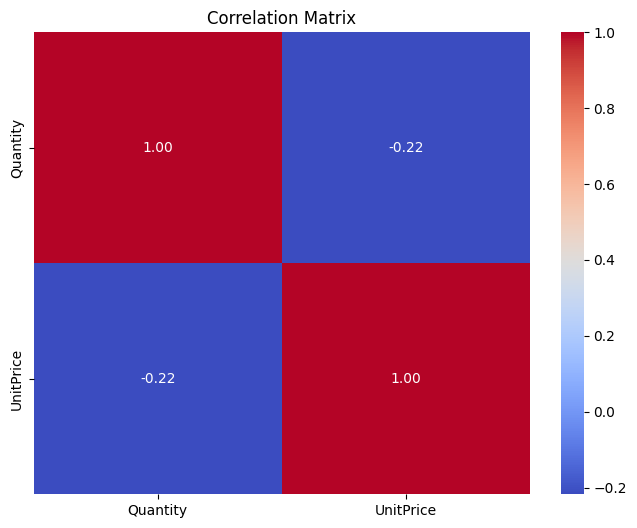

In [ ]:
# Compute correlation matrix
numerical_data = sales_data.select(["Quantity", "UnitPrice"]).toPandas()
correlation_matrix = numerical_data.corr()

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


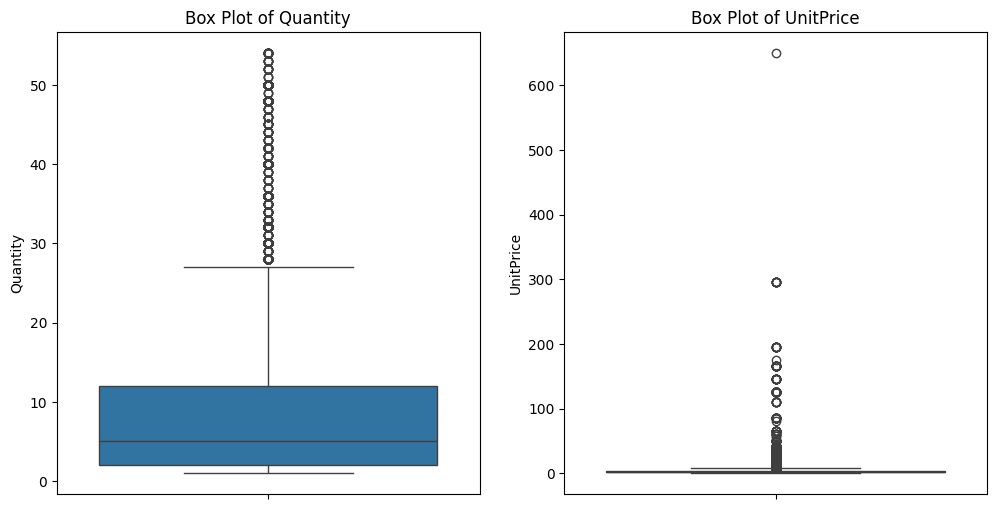

In [ ]:
# Plot box plot for Quantity and UnitPrice
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=numerical_data["Quantity"])
plt.title('Box Plot of Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=numerical_data["UnitPrice"])
plt.title('Box Plot of UnitPrice')

plt.show()


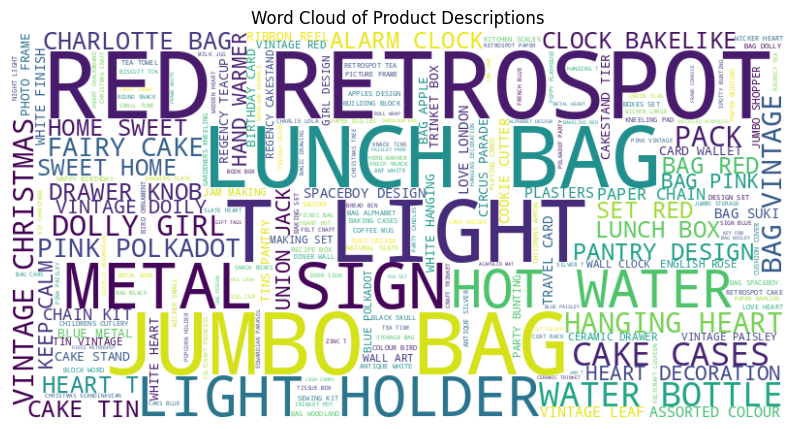

In [ ]:
# Generate word cloud for descriptions
descriptions = sales_data.select("Description").rdd.flatMap(lambda x: x).collect()
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(descriptions))

# Plot word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Product Descriptions')
plt.show()


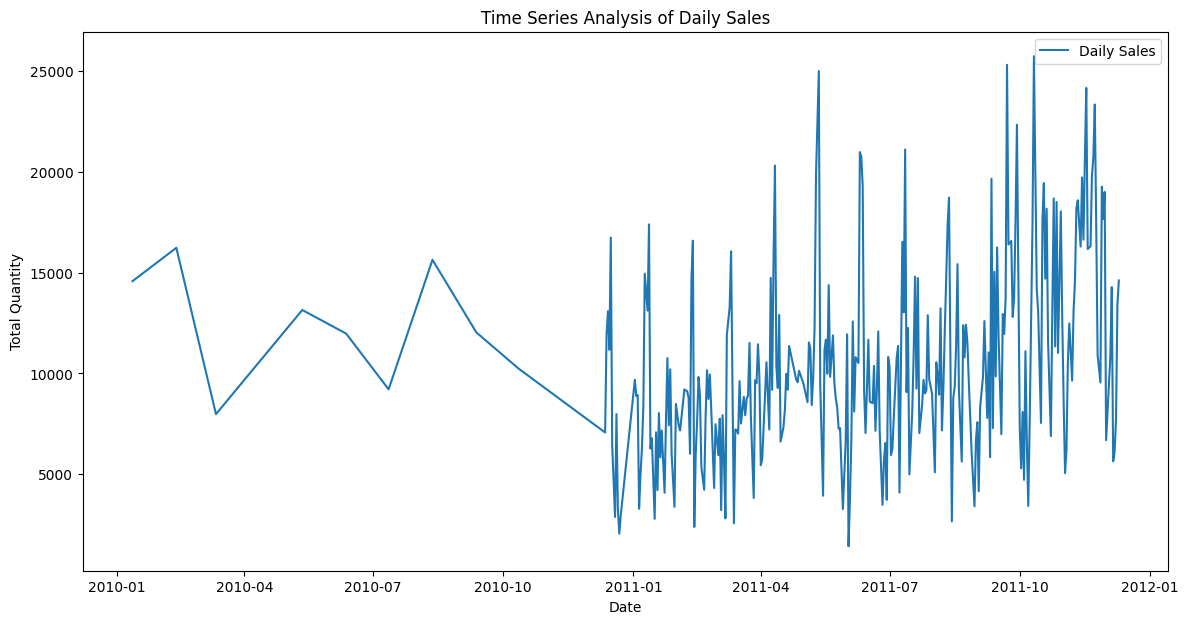

In [ ]:
# Aggregate data by date for time series analysis
daily_sales = sales_data.groupBy("InvoiceDate").agg({"Quantity": "sum"}).orderBy("InvoiceDate")
daily_sales = daily_sales.withColumnRenamed("sum(Quantity)", "TotalQuantity")

# Convert to Pandas DataFrame for plotting
daily_sales_df = daily_sales.toPandas()

# Plot time series
plt.figure(figsize=(14, 7))
plt.plot(daily_sales_df["InvoiceDate"], daily_sales_df["TotalQuantity"], label='Daily Sales')
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.title('Time Series Analysis of Daily Sales')
plt.legend()
plt.show()


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import StringIndexer
from pyspark.ml.evaluation import RegressionEvaluator

# Split the data into training and testing sets based on the split date "2011-09-25"
split_date_train_test = "2011-09-25"
train_data = sales_data.filter(col("InvoiceDate") <= split_date_train_test)
test_data = sales_data.filter(col("InvoiceDate") > split_date_train_test)

# Convert to pandas DataFrame
pd_daily_train_data = train_data.select("Country", "StockCode", "InvoiceDate", "Quantity").toPandas()

# Create indexers for categorical columns
country_indexer = StringIndexer(inputCol="Country", outputCol="CountryIndex").setHandleInvalid("keep")
stock_code_indexer = StringIndexer(inputCol="StockCode", outputCol="StockCodeIndex").setHandleInvalid("keep")

# Select feature columns
feature_cols = ["CountryIndex", "StockCodeIndex", "Month", "Year", "DayOfWeek", "Day", "Week"]

# Use VectorAssembler to combine features
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Initialize Random Forest model
rf = RandomForestRegressor(featuresCol="features", labelCol="Quantity", maxBins=4000)

# Create a pipeline for staging the processes
pipeline = Pipeline(stages=[country_indexer, stock_code_indexer, assembler, rf])

# Train the model
model = pipeline.fit(train_data)

# Get test predictions
test_predictions = model.transform(test_data)
test_predictions = test_predictions.withColumn("prediction", col("prediction").cast("double"))

# Provide the Mean Absolute Error (MAE) for the forecast
mae_evaluator = RegressionEvaluator(labelCol="Quantity", predictionCol="prediction", metricName="mae")
mae = mae_evaluator.evaluate(test_predictions)

# Get the weekly sales of all countries
weekly_test_predictions = test_predictions.groupBy("Year", "Week").agg({"prediction": "sum"})

# Find the quantity sold during week 39 of 2011
promotion_week = weekly_test_predictions.filter(col('Week') == 39)
quantity_sold_w39 = int(promotion_week.select("sum(prediction)").collect()[0][0])

# Display the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Quantity Sold in Week 39 of 2011: {quantity_sold_w39}")

# Display first few rows of training data
pd_daily_train_data.head()




In [ ]:
# Display summary statistics of predictions
test_predictions.describe(["Quantity", "prediction"]).show()

# Show a sample of the prediction errors
test_predictions.withColumn("error", col("Quantity") - col("prediction")).select("InvoiceDate", "Quantity", "prediction", "error").show(5)

# Plot predicted values only
import pandas as pd

# Convert to Pandas DataFrame for plotting
predictions_pd = test_predictions.select("InvoiceDate", "prediction").toPandas()

plt.figure(figsize=(14, 7))
plt.plot(predictions_pd["InvoiceDate"], predictions_pd["prediction"], label='Predicted Quantity', alpha=0.7, color='orange')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.title('Predicted Quantity')
plt.legend()
plt.show()



In [ ]:
my_spark.stop()

13729
